<a href="https://colab.research.google.com/github/eyluelo/eeg-mental-state-classification/blob/main/eeg_mental_state_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [2]:
import numpy
import pandas
import matplotlib


print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("matplotlib:", matplotlib.__version__)

numpy: 2.0.2
pandas: 2.2.2
matplotlib: 3.10.0


In [3]:
import os
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')

print("kaggle credentials set")

kaggle credentials set


In [4]:
!kaggle datasets download -d birdy654/eeg-brainwave-dataset-mental-state

Dataset URL: https://www.kaggle.com/datasets/birdy654/eeg-brainwave-dataset-mental-state
License(s): other
100% 24.1M/24.1M [00:00<00:00, 56.0MB/s]



In [5]:
import zipfile
with zipfile.ZipFile("eeg-brainwave-dataset-mental-state.zip", "r") as zip_ref:
  zip_ref.extractall("eeg_data")
print("zip file extracted")

zip file extracted


In [6]:
import os
os.listdir("eeg_data")

['mental-state.csv']

In [7]:
df = pandas.read_csv("eeg_data/mental-state.csv")
df.head()

,lag1_mean_0,lag1_mean_1,lag1_mean_2,lag1_mean_3,lag1_mean_d_h2h1_0,lag1_mean_d_h2h1_1,lag1_mean_d_h2h1_2,lag1_mean_d_h2h1_3,lag1_mean_q1_0,lag1_mean_q1_1,...,freq_669_3,freq_679_3,freq_689_3,freq_699_3,freq_709_3,freq_720_3,freq_730_3,freq_740_3,freq_750_3,Label
0,25.781648,33.836367,-92.769629,19.187957,-1.542262,0.197462,-119.561133,2.032654,21.596272,33.965587,...,0.000230,0.000351,0.000547,0.000381,0.000350,0.000453,0.000442,0.000325,0.000209,2.0
1,29.357891,26.792566,417.203910,19.472121,-38.797263,-16.897194,-29.368531,-9.055370,44.647424,40.893307,...,0.001671,0.000740,0.001122,0.000521,0.000624,0.000439,0.001249,0.000727,0.000801,2.0
2,28.451926,31.076434,72.231301,14.245938,-13.225057,-0.614138,-28.331698,-8.858742,31.450289,30.692883,...,0.000748,0.000569,0.000327,0.000197,0.000833,0.000909,0.000699,0.001165,0.000616,2.0
3,21.282184,19.985184,16.220094,39.787312,1.847866,0.670216,-1.820355,20.220724,21.404679,20.777411,...,0.000990,0.005644,0.006891,0.010546,0.009583,0.011158,0.008853,0.004551,0.002287,1.0
4,20.431516,28.982168,27.540246,19.960398,2.491458,-6.020503,-1.071166,2.655259,16.295039,32.658163,...,0.001659,0.014379,0.014492,0.002949,0.004575,0.008305,0.007202,0.006957,0.009836,2.0


In [8]:
print(df.shape)
df.describe()
print(df.columns)

print(df.columns[-1])
df['Label'].unique()
df['Label'].value_counts()

(2479, 989)
Index(['lag1_mean_0', 'lag1_mean_1', 'lag1_mean_2', 'lag1_mean_3',
       'lag1_mean_d_h2h1_0', 'lag1_mean_d_h2h1_1', 'lag1_mean_d_h2h1_2',
       'lag1_mean_d_h2h1_3', 'lag1_mean_q1_0', 'lag1_mean_q1_1',
       ...
       'freq_669_3', 'freq_679_3', 'freq_689_3', 'freq_699_3', 'freq_709_3',
       'freq_720_3', 'freq_730_3', 'freq_740_3', 'freq_750_3', 'Label'],
      dtype='object', length=989)
Label


,count
Label,
2.0,830
1.0,830
0.0,819


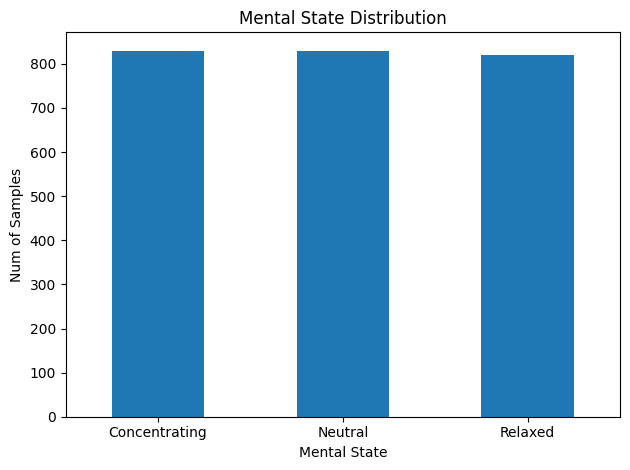

In [9]:
ax = df['Label'].value_counts().plot(kind='bar')

ax.set_title("Mental State Distribution")
ax.set_xlabel("Mental State")
ax.set_ylabel("Num of Samples")
ax.set_xticklabels(['Concentrating', 'Neutral', 'Relaxed'], rotation=0)

matplotlib.pyplot.tight_layout()
matplotlib.pyplot.show()


In [10]:
X = df.drop(columns=['Label'])
y = df['Label']

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size: ", X_train.shape)
print("Test size: ", X_test.shape)

Train size:  (1983, 988)
Test size:  (496, 988)


In [12]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Training complete.")

Training complete.


In [13]:
y_pred = model.predict(X_test)
print(y_pred[:10])
print(y_test[:10].values)

[1. 2. 0. 0. 2. 1. 0. 0. 1. 0.]
[1. 2. 0. 0. 2. 1. 0. 0. 1. 0.]


In [14]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  0.9616935483870968


In [15]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['Relaxed', 'Neutral', 'Concentrating']))

               precision    recall  f1-score   support

      Relaxed       1.00      0.96      0.98       167
      Neutral       0.96      0.93      0.95       167
Concentrating       0.93      1.00      0.96       162

     accuracy                           0.96       496
    macro avg       0.96      0.96      0.96       496
 weighted avg       0.96      0.96      0.96       496



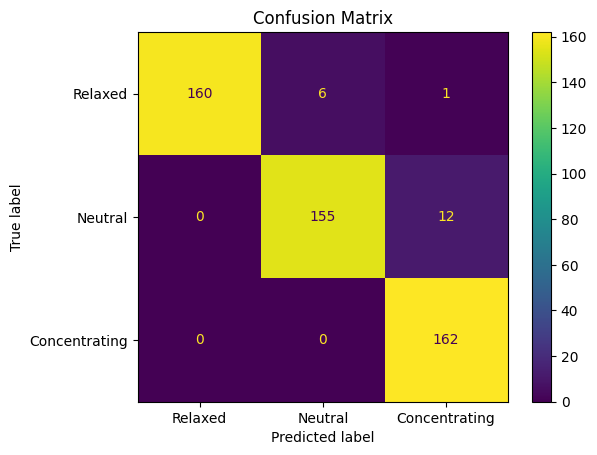

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Relaxed', 'Neutral', 'Concentrating'])
matplotlib.pyplot.title("Confusion Matrix")
matplotlib.pyplot.show()

In [17]:
feature_importance_df = pandas.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print(feature_importance_df)

              Feature  Importance
646        eigenval_0    0.029004
526             std_2    0.022128
145  lag1_logcovM_2_2    0.017839
38         lag1_std_2    0.016441
55         lag1_max_3    0.014707
..                ...         ...
222   lag1_freq_355_0    0.000016
671       topFreq_2_1    0.000015
514     mean_d_q2q3_2    0.000014
397   lag1_freq_689_2    0.000012
682       topFreq_3_2    0.000000

[988 rows x 2 columns]


In [19]:
top_20 = feature_importance_df.head(20)
print(top_20)

              Feature  Importance
646        eigenval_0    0.029004
526             std_2    0.022128
145  lag1_logcovM_2_2    0.017839
38         lag1_std_2    0.016441
55         lag1_max_3    0.014707
536            kurt_0    0.014162
134   lag1_eigenval_0    0.014080
657       logcovM_2_2    0.013476
610          min_q4_2    0.013216
126     lag1_covM_0_2    0.010943
415   lag1_freq_122_3    0.010136
102     lag1_min_q2_2    0.010021
413   lag1_freq_101_3    0.010018
131     lag1_covM_2_2    0.009587
98      lag1_min_q1_2    0.009560
414   lag1_freq_111_3    0.009337
48        lag1_kurt_0    0.009011
643          covM_2_2    0.008234
590             min_2    0.008223
602          min_q2_2    0.008187


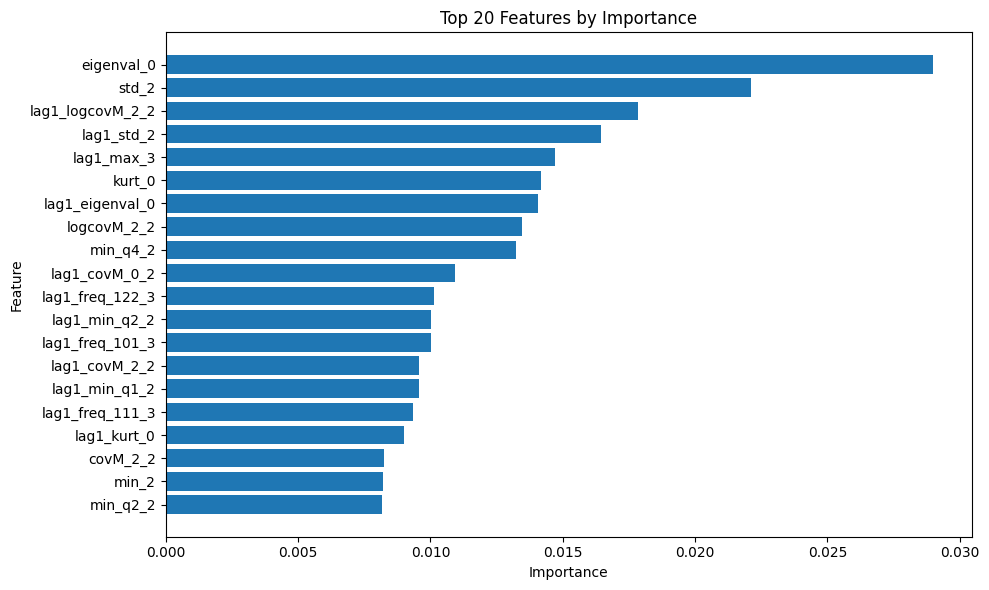

In [24]:
matplotlib.pyplot.figure(figsize=(10, 6))
matplotlib.pyplot.barh(top_20['Feature'], top_20['Importance'])
matplotlib.pyplot.title('Top 20 Features by Importance')
matplotlib.pyplot.xlabel('Importance')
matplotlib.pyplot.ylabel('Feature')
matplotlib.pyplot.gca().invert_yaxis()
matplotlib.pyplot.tight_layout()
matplotlib.pyplot.show()

In [28]:
for electrode, code in [('TP9' , '_0'), ('AF7', '_1'), ('AF8', '_2'), ('TP10', '_3')]:
  no = top_20['Feature'].str.endswith(code).sum()
  print(f"{electrode}: {no} feature")

TP9: 4 feature
AF7: 0 feature
AF8: 12 feature
TP10: 4 feature


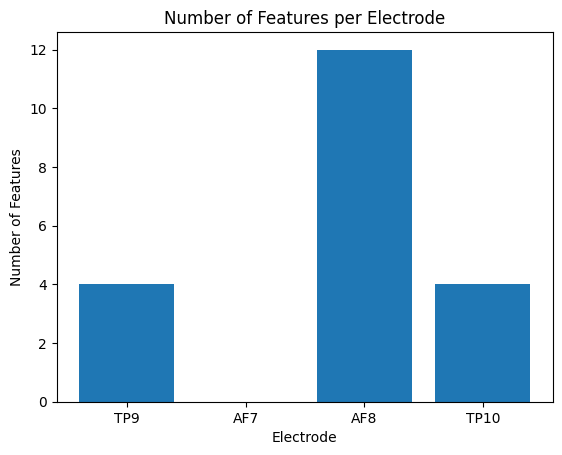

In [31]:
electrode_counts = {
    'TP9': 4,
    'AF7': 0,
    'AF8': 12,
    'TP10': 4
}
matplotlib.pyplot.bar(electrode_counts.keys(), electrode_counts.values())
matplotlib.pyplot.xlabel('Electrode')
matplotlib.pyplot.ylabel('Number of Features')
matplotlib.pyplot.title('Number of Features per Electrode')
matplotlib.pyplot.show()

